In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable, Optional

In [73]:
def update_model(theta, z, loss, eta=0.1):
    theta.requires_grad_(True)
    theta.grad = None
    
    # Compute loss and gradient
    l_t = loss(z, theta).mean(dim=-1)
    l_t.backward()
    dL1 = theta.grad
    
    with torch.no_grad(): # Update theta
        theta = theta - eta * dL1
    
    return theta.detach()

def RGD(
    D_theta: Callable,
    loss: Callable,
    theta_0: torch.Tensor,
    mu: Callable,
    sigma: float,
    poison_function: Optional[Callable] = None,
    n: int = 1000,
    eta: float = 0.1,
    max_iter: int = 100,
    **poison_kwargs
):

    all_thetas = [theta_0.clone().detach().squeeze()]
    all_losses = []

    theta_t = theta_0
    t = 0
    
    while t < max_iter:
        
        # Draw n samples from D(theta)
        z = D_theta(theta_t, n)

        if poison_function is not None:
            z = poison_function(z, theta_t, mu=mu, sigma=sigma, loss=loss, eta=eta, **poison_kwargs)

        # Compute gradient of loss (dL1)
        theta_t = update_model(theta_t, z, loss, eta)

        # Check for NaNs in theta_t or z (supports torch.Tensor and numpy arrays)
        nan_in_theta = torch.isnan(theta_t).any().item() if isinstance(theta_t, torch.Tensor) else np.isnan(theta_t).any()
        if nan_in_theta:
            print(f"NaN detected in theta_t at iteration {t}. Stopping optimization.")
            break

        nan_in_z = torch.isnan(z).any().item() if isinstance(z, torch.Tensor) else np.isnan(z).any()
        if nan_in_z:
            print(f"NaN detected in z at iteration {t}. Stopping optimization.")
            break
            
        # Record loss on TRUE (not poisoned) distribution
        z_true = D_theta(theta_t, n)
        all_losses.append(loss(z_true, theta_t).item())

        all_thetas.append(theta_t.detach().squeeze())
        
        t += 1
    
    return theta_t, all_thetas, all_losses

def oracle_poison_function(
    z: torch.Tensor, 
    theta: torch.Tensor, 
    theta_update_estimator: Callable,
    mu: Callable,
    sigma: torch.Tensor,
    loss: Callable,
    eta: float,
    num_steps: int = 10, 
    step_size: float = 0.1, 
    epsilon: float = 1e-6,
    norm = 'linf', # 'l2' or 'linf'
    ):
    
    z_0 = z.clone().detach()
    for _ in range(num_steps): 
       
        z.requires_grad_(True)
        z.grad = None
        
        theta_new = theta_update_estimator(z, theta, eta)
        assert theta_new.shape == theta.shape, "Shape mismatch in theta update estimator."

        mu_new = mu(theta_new)
        assert mu_new.shape == z.shape[:1], f"Shape mismatch in mu function: expected {z.shape[0]}, got {mu_new.shape}."
        
        z_new = mu_new.unsqueeze(-1) + sigma @ torch.randn_like(z)
        assert z_new.shape == z.shape, f"Shape mismatch in z_new: expected {z.shape}, got {z_new.shape}."
        
        l_theta = loss(z_new, theta_new)
        
        l_theta.backward()
        dz = z.grad
        
        with torch.no_grad():
            z += step_size * dz / (torch.norm(dz, dim=0, keepdim=True) + 1e-16)
            delta = z - z_0
            if norm == 'l2':
                delta_norm = torch.norm(delta, p=2, dim=0, keepdim=True) + 1e-16
                exceed_mask = (delta_norm > epsilon).float()
                delta = delta * (epsilon / delta_norm) * exceed_mask + delta * (1 - exceed_mask)
            elif norm == 'linf':
                delta_norm = torch.max(torch.abs(delta), dim=0, keepdim=True)[0] + 1e-16
                exceed_mask = (delta_norm > epsilon).float()
                delta = delta * (epsilon / delta_norm) * exceed_mask + delta * (1 - exceed_mask)
            assert delta.shape == z.shape, f"Shape mismatch in delta: expected {z.shape}, got {delta.shape}."
            z = z_0 + delta
            
    return z.detach()

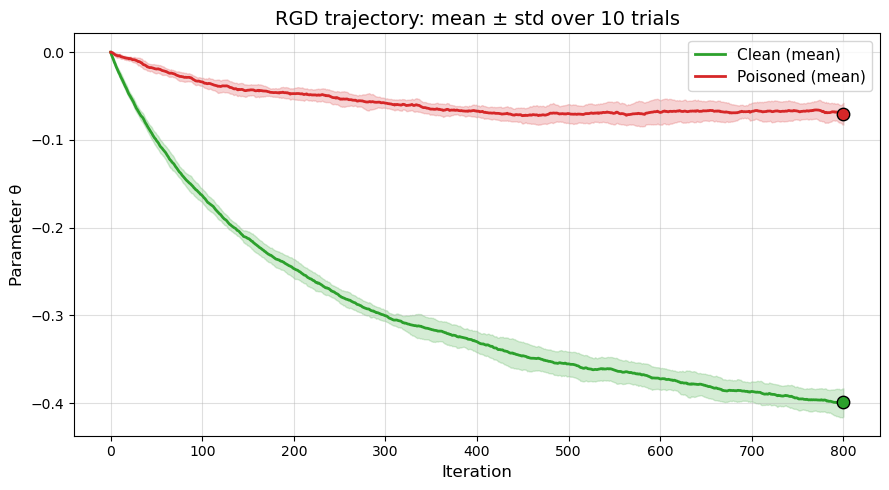

In [81]:
a0 = 1.0
a1 = 0.5
sigma = torch.tensor([[1.0]])
mu = lambda theta:(a0*theta + a1)**2
D_theta = lambda theta, n: torch.normal(mu(theta).squeeze(), 1.0, size=(1,n))
loss = lambda z, theta: (z*theta).mean(-1)

def theta_update_estimator(z, theta, eta):
    theta.requires_grad_(True)
    theta.grad = None
    
    # Compute loss and gradient
    l_t = loss(z, theta).mean(dim=-1)
    dL1 = torch.autograd.grad(l_t, theta, create_graph=True)[0]
    
    # Update theta
    theta_new = theta - eta * dL1

    return theta_new

poison_kwargs = {
    'num_steps': 20,
    'step_size': 0.1,
    'epsilon': 2e-1,
    'theta_update_estimator': theta_update_estimator
}

theta_0=torch.tensor([0.0])
n_trials = 10

def run_trial():

    _, all_theta_clean, _ = RGD(
        D_theta=D_theta,
        loss=loss,
        mu=mu,
        sigma=sigma,
        theta_0=theta_0.clone(),
        n=100,
        eta=0.01,
        max_iter=800,
        poison_function=None
    )
    _, all_theta_poisoned, _ = RGD(
        D_theta=D_theta,
        loss=loss,
        mu=mu,
        sigma=sigma,
        theta_0=theta_0.clone(),
        n=100,
        eta=0.01,
        max_iter=800,
        poison_function=oracle_poison_function,
        **poison_kwargs
    )
    
    return all_theta_clean, all_theta_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean)
    all_theta_poisoned_list.append(all_theta_poisoned)

# Aggregate across trials and plot mean ± std
def to_float_array(traj):
    return torch.tensor([t.item() if hasattr(t, "item") else float(t) for t in traj], dtype=torch.float32)

clean_stack = torch.stack([to_float_array(traj) for traj in all_theta_clean_list])      # [n_trials, T]
poison_stack = torch.stack([to_float_array(traj) for traj in all_theta_poisoned_list])  # [n_trials, T]

clean_mean = clean_stack.mean(dim=0).numpy()
clean_std  = clean_stack.std(dim=0, unbiased=False).numpy()
poison_mean = poison_stack.mean(dim=0).numpy()
poison_std  = poison_stack.std(dim=0, unbiased=False).numpy()

x = np.arange(clean_mean.shape[0])

fig, ax = plt.subplots(figsize=(9,5))

ax.plot(x, clean_mean, label='Clean (mean)', color='tab:green', linewidth=2)
ax.fill_between(x, clean_mean - clean_std, clean_mean + clean_std, color='tab:green', alpha=0.2)

ax.plot(x, poison_mean, label='Poisoned (mean)', color='tab:red', linewidth=2)
ax.fill_between(x, poison_mean - poison_std, poison_mean + poison_std, color='tab:red', alpha=0.2)

ax.scatter(x[-1], clean_mean[-1], color='tab:green', edgecolor='k', s=80, zorder=5)
ax.scatter(x[-1], poison_mean[-1], color='tab:red', edgecolor='k', s=80, zorder=5)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Parameter θ', fontsize=12)
ax.set_title(f'RGD trajectory: mean ± std over {clean_stack.shape[0]} trials', fontsize=14)
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

# Pricing Example

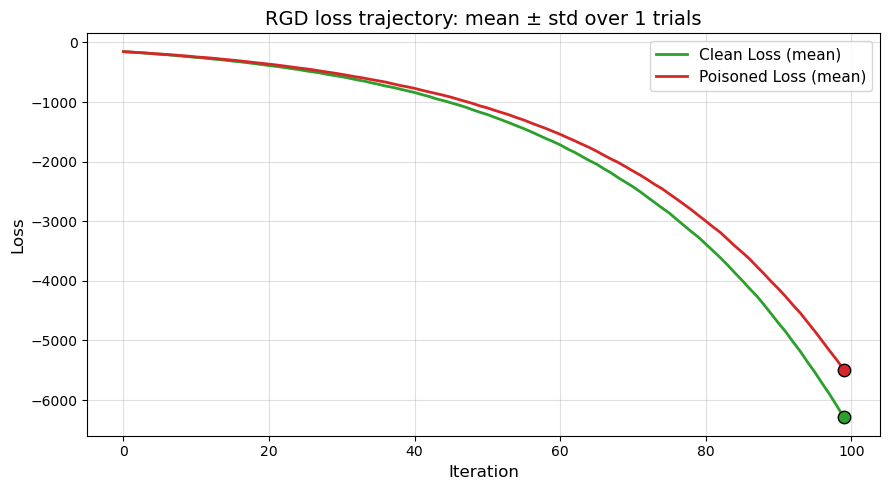

In [78]:
def pricing(mu_0: torch.Tensor = torch.Tensor([6.55,6.72,6.60,6.54,6.42]), 
            sigma: torch.Tensor = torch.eye(5), 
            eps: float = 1.5
    ):

    mu = lambda theta: mu_0 + eps * theta

    def D_theta(theta: torch.Tensor, n: int) -> torch.Tensor:
        return torch.distributions.MultivariateNormal(mu(theta), sigma).sample((n,)).T
    
    def loss(z: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
        return torch.mean(-theta.reshape(1, -1) @ z)
    
    info = {"theta_optimal": mu_0 / (2 * eps), "theta_stable": mu_0 / eps}

    return D_theta, loss, mu, info

sigma = torch.eye(5)
n_trials = 1

poison_kwargs = {
    'num_steps': 20,
    'step_size': 0.1,
    'epsilon': 1,
    'theta_update_estimator': theta_update_estimator
}

D_theta, loss, mu, info = pricing()

def run_trial(theta_0):

    _, all_theta_clean, all_losses_clean = RGD(
        D_theta=D_theta,
        loss=loss,
        mu=mu,
        sigma=sigma,
        theta_0=theta_0.clone(),
        n=100,
        eta=0.01,
        max_iter=100,
        poison_function=None
    )
    _, all_theta_poisoned, all_losses_poisoned = RGD(
        D_theta=D_theta,
        loss=loss,
        mu=mu,
        sigma=sigma,
        theta_0=theta_0.clone(),
        n=100,
        eta=0.01,
        max_iter=100,
        poison_function=oracle_poison_function,
        **poison_kwargs
    )
    
    return all_losses_clean, all_losses_poisoned

all_losses_clean_list = []
all_losses_poisoned_list = []

for trial in range(n_trials):
    all_losses_clean, all_losses_poisoned = run_trial(theta_0 = 5 * torch.rand(5))
    all_losses_clean_list.append(all_losses_clean)
    all_losses_poisoned_list.append(all_losses_poisoned)

# Aggregate across trials and plot mean ± std for losses
def to_float_array_losses(traj):
    return torch.tensor([t.item() if hasattr(t, "item") else float(t) for t in traj], dtype=torch.float32)

clean_stack = torch.stack([to_float_array_losses(traj) for traj in all_losses_clean_list])      # [n_trials, T]
poison_stack = torch.stack([to_float_array_losses(traj) for traj in all_losses_poisoned_list])  # [n_trials, T]

clean_mean = clean_stack.mean(dim=0).numpy()
clean_std  = clean_stack.std(dim=0, unbiased=False).numpy()
poison_mean = poison_stack.mean(dim=0).numpy()
poison_std  = poison_stack.std(dim=0, unbiased=False).numpy()

x = np.arange(clean_mean.shape[0])

fig, ax = plt.subplots(figsize=(9,5))

ax.plot(x, clean_mean, label='Clean Loss (mean)', color='tab:green', linewidth=2)
ax.fill_between(x, clean_mean - clean_std, clean_mean + clean_std, color='tab:green', alpha=0.2)

ax.plot(x, poison_mean, label='Poisoned Loss (mean)', color='tab:red', linewidth=2)
ax.fill_between(x, poison_mean - poison_std, poison_mean + poison_std, color='tab:red', alpha=0.2)

ax.scatter(x[-1], clean_mean[-1], color='tab:green', edgecolor='k', s=80, zorder=5)
ax.scatter(x[-1], poison_mean[-1], color='tab:red', edgecolor='k', s=80, zorder=5)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title(f'RGD loss trajectory: mean ± std over {clean_stack.shape[0]} trials', fontsize=14)
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()